# Heatmaps

Heatmaps are a compact and effective way to visualise matrix-style data, especially in biomedical and statistical applications. Each cell’s colour reflects a numerical value, often used to show correlations, effect sizes, expression levels, or statistical significance.

To illustrate the plot-misc code for these illustrations we will first define some plotting constants and load some toy example data. 

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plot_misc.example_data.examples as examples
import plot_misc.heatmap as heatmap
import plot_misc.utils.utils as pm_utils

In [2]:
# import example data
matrix = examples.load_heatmap_data()

# Constants

# conversion factor: centimetres → inches
CMTOINCH = 1 / 2.54   
# Colourbar label and formatting
CBAR_FSIZE = 6    # colourbar axis label font size (pt)
CBAR_FTSIZE = 4   # colourbar tick label font size (pt)
# CBAR_LABEL uses LaTeX math: "direction × −log₁₀(p)" — a signed significance score
CBAR_LABEL = r"dir $\times -\log_{10}$(p)"

# Grid and tick styling
LWD = 1.5    # grid line width (pt)
PAD = 1.5    # tick label padding (pt)
COLB = "b"   # tick mark colour ("b" = blue in matplotlib shorthand)
LENT = 3     # tick length (pt)

# Colourmap: PiYG diverging palette with CMAP_N discrete steps
CMAP_N = 13
cmap = plt.get_cmap("PiYG", CMAP_N)

# Boundary values for the diverging colourmap (centred on 0)
bounds = [-8, -6, -4, -2, 0, 2, 4, 6, 8]
# MidpointNormalize centres the colourmap at 0 so that positive and negative
# values are scaled symmetrically regardless of their absolute range
norm = pm_utils.MidpointNormalize(vcenter=0, vmin=-8, vmax=8)

# print data
print(matrix.head())

           exposure_0  exposure_1  exposure_2  exposure_3  exposure_4  \
outcome_0       -0.68        0.20       -1.67        1.65        3.21   
outcome_1        0.01        0.56        0.05        0.40        0.54   
outcome_2       -0.38        2.93        0.83        0.10        0.96   
outcome_3       -2.15       -1.10       -1.14        2.44       -0.87   
outcome_4       -1.72       -0.37       -1.27        3.26       -0.46   

           exposure_5  exposure_6  exposure_7  exposure_8  exposure_9  ...  \
outcome_0        0.59       -1.23       -0.93        7.06       -0.39  ...   
outcome_1        1.52       -0.69        0.96        1.96        1.48  ...   
outcome_2        0.54        0.37       -1.56       -0.38        1.04  ...   
outcome_3       -1.04       -0.14       -0.05       -2.85        0.32  ...   
outcome_4       -1.25       -0.48        0.23       -8.00        0.22  ...   

           exposure_12  exposure_13  exposure_14  exposure_15  exposure_16  \
outcome_0     

## Heatmaps 

In the code below, we create a heatmap with the original values added as an annotation layer, displayed directly on top of the coloured cells. This can be helpful to enhances interpretability by making both the direction and magnitude of the values immediately visible.

In addition, we include vertical lines to highlight groups of particular interest; for example, categories of biomarkers or predefined clinical domains.

_Note:_ The `annotation_heatmap` function can accept any matrix of text-based annotations, provided it has the same dimensions as the data used for the heatmap. Possible alternatives include:
- Formatted *p*-values
- Effect size labels
- Symbols indicating statistical significance or enrichment


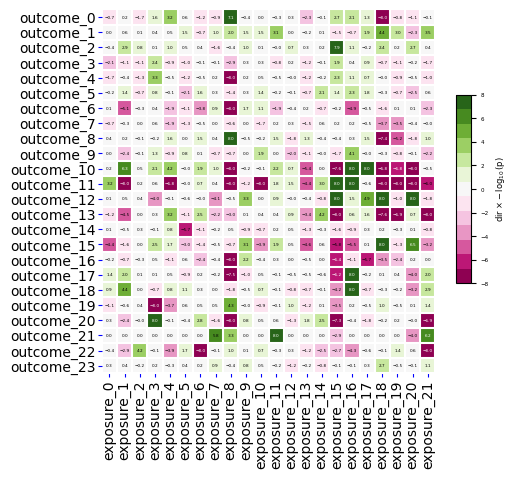

In [3]:
fig, ax = plt.subplots(1, figsize=(12 * CMTOINCH, 12 * CMTOINCH))
# location of cbar
cbar_ax = fig.add_axes([0.91, 0.3, 0.03, 0.4])
# plotting heatmap
im, cbar = heatmap.heatmap(
    data=matrix,
    row_labels=matrix.index.to_list(),
    col_labels=matrix.columns.to_list(),
    ax=ax,
    cmap=cmap,
    norm=norm,
    grid_linewidth=LWD,
)
# adding annotation
texts = heatmap.annotate_heatmap(im, threshold=6, valfmt="{x:.1f}", fontsize=3)

# adding cbar
fig.colorbar(
    mpl.cm.ScalarMappable(norm=norm, cmap=cmap),
    cax=cbar_ax,
    orientation="vertical",
    extend="neither",
)
# cbar formatting
cbar_ax.set_ylabel(CBAR_LABEL, fontsize=CBAR_FSIZE, rotation=90, labelpad=4)
cbar_ax.tick_params(labelsize=CBAR_FTSIZE)

# ticks
im.axes.tick_params(pad=PAD, color=COLB, length=LENT, bottom=True)
_ = im.axes.set_xticklabels(im.axes.get_xmajorticklabels(), rotation=90, va="center")

## Masked heatmaps

Sometimes only a subset of the matrix should be shown; for example the biomarker–outcome pairs that pass a quality-control (QC) check, or the associations that reach significance. `masked_heatmap` draws the matrix in two layers:

1. a single-colour **background** covering every cell (optionally carrying a grid lattice), and
2. the **heatmap** itself, restricted to the cells flagged by a binary `indicator` table of the same shape as `data`.

Below we use a toy QC dataset where we only want to plot the outliers that do not pass the QC threshold. 

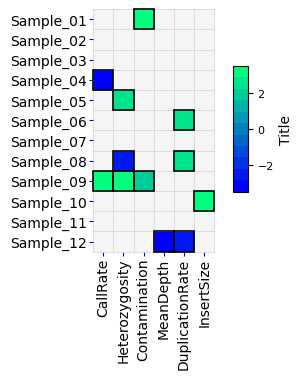

In [4]:
# QC values and the matching binary pass/fail indicator (same shape)
qc_values, qc_indicator = examples.get_data("qc_matrix")

# diverging colourmap centred on zero (signed QC deviations)
cmap = plt.get_cmap("winter", 11)
norm = pm_utils.MidpointNormalize(vcenter=0, vmin=-3.5, vmax=3.5)

fig, ax = plt.subplots(1, figsize=(6 * CMTOINCH, 8 * CMTOINCH))
# location of cbar
cbar_ax = fig.add_axes([0.85, 0.3, 0.06, 0.4])

# draw only the QC failures (indicator == 1) on a light-grey background
im, _ = heatmap.masked_heatmap(
    data=qc_values,
    indicator=qc_indicator,
    row_labels=qc_values.index.to_list(),
    col_labels=qc_values.columns.to_list(),
    background_col="whitesmoke",       
    background_gridcol="lightgrey",  
    background_linewidth=0.5,
    outline_col="black",         
    outline_linewidth=1.2,
    outline_zorder=2,
    cmap=cmap,
    norm=norm,
    ax=ax,
)

# adding cbar
fig.colorbar(
    mpl.cm.ScalarMappable(norm=norm, cmap=cmap),
    cax=cbar_ax,
    orientation="vertical",
    extend="neither",
)
# cbar formatting
cbar_ax.set_ylabel("Title", fontsize=10, rotation=90, labelpad=4)
cbar_ax.tick_params(labelsize=8)

# ticks
im.axes.tick_params(pad=PAD, color=COLB, length=LENT, bottom=True)
_ = im.axes.set_xticklabels(im.axes.get_xmajorticklabels(), rotation=90, va="center")